In [1]:
import torch
import model as mc
import pandas as pd
from epiweeks import Week
import preprocess_data as prep
import matplotlib.pyplot as plt 
from mosqlient.scoring import Scorer


pd.options.mode.chained_assignment = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

regioes_estados = {
        'Sul': ['SC', 'PR', 'RS'],
        'Sudeste': ['SP', 'MG', 'RJ', 'ES'],
        'Nordeste': ['BA', 'CE', 'PE', 'PB', 'PI', 'RN', 'MA', 'AL', 'SE'],
        'Centro-Oeste': ['DF', 'MT', 'MS', 'GO'],
        'Norte': ['RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO']
    } 
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


columns_to_normalize_enso = ['casos','epiweek', 'biome', 'enso']

columns_to_normalize = ['casos','epiweek', 'biome']

predict_n = 52
max_epiweek = 22
    
boxcox = False

TEST_YEAR = 2023

In [2]:
media = True
min_year = 2015
doenca = 'dengue'
#model_name = 'enso'

enso = prep.load_enso_weekly()
df = prep.load_cases_data(filename= f'./data/{doenca}.csv.gz')

In [3]:
model_base = 'base_22'
model_enso = 'enso_22'
model_mix = 'mix_22'

In [4]:
from pathlib import Path

def make_pred(
    df_reg_agg,
    df_reg,
    enso,
    doenca,
    region,
    TEST_YEAR,
    columns_to_normalize,
    model_name,
    media=True
):

    pred_path = Path(
        f"predictions/preds_{doenca}_{region}_{TEST_YEAR}_{model_name}.csv"
    )

    if pred_path.exists():

        print(f"Loading {pred_path}")

        df_preds1 = pd.read_csv(
            pred_path,
            index_col=0        )

        df_preds1.date = pd.to_datetime(df_preds1.date, format="%Y-%m-%d")

    else:

        model1 = mc.load_model(
            region,
            TEST_YEAR,
            doenca,
            model_name,
            predict_n,
            max_epiweek,
            device
        )

        df_preds1 = mc.sum_regions_predictions(
            model1,
            df_reg,
            enso,
            TEST_YEAR,
            columns_to_normalize,
            max_epiweek=max_epiweek,
            boxcox=boxcox,
            n_passes=500,
            min_year=min_year,
            media=media
        )

        df_preds1.to_csv(pred_path)

    score = Scorer(
        api_key='',
        df_true=df_reg_agg,
        pred=df_preds1,
    )

    mean_sc1 = score.wis[1]['pred']

    return df_preds1, mean_sc1



Sul
Loading predictions/preds_dengue_Sul_2023_base_22.csv
Loading predictions/preds_dengue_Sul_2023_enso_22.csv
Loading predictions/preds_dengue_Sul_2023_mix_22.csv


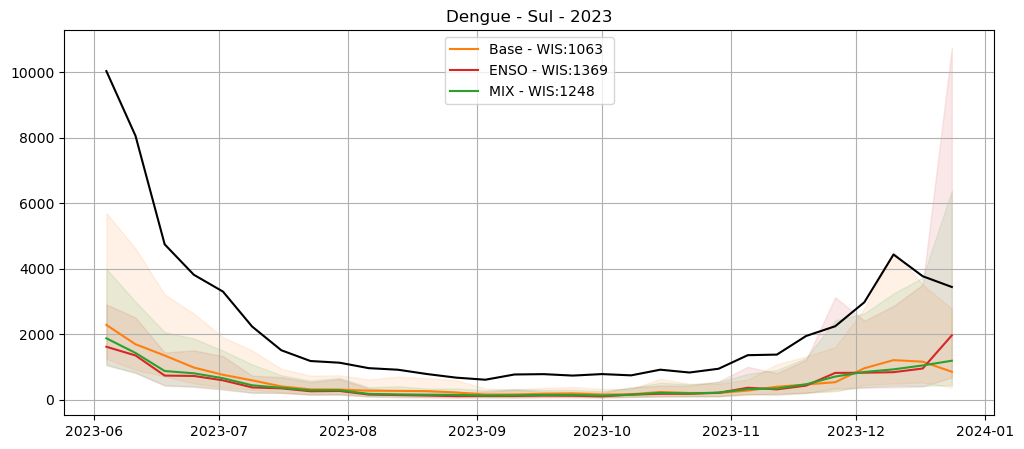

Sudeste
Loading predictions/preds_dengue_Sudeste_2023_base_22.csv
Loading predictions/preds_dengue_Sudeste_2023_enso_22.csv
Loading predictions/preds_dengue_Sudeste_2023_mix_22.csv


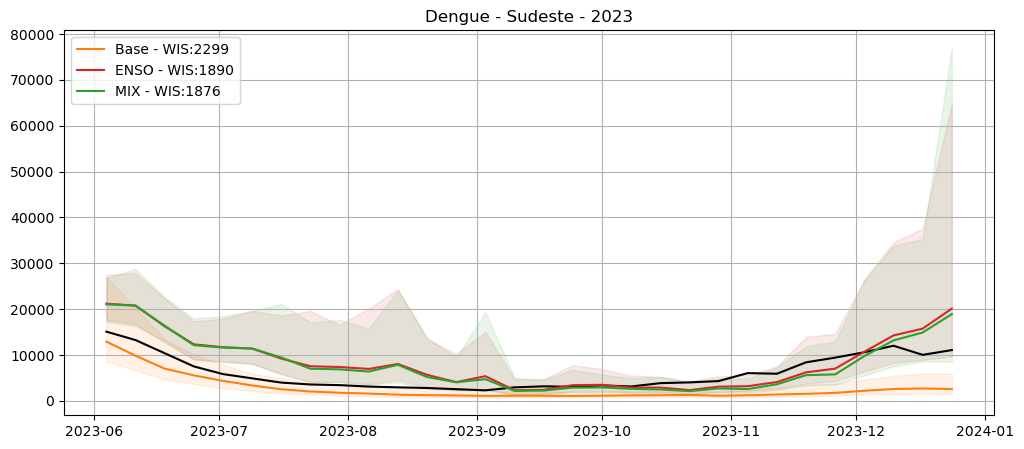

Nordeste
Loading predictions/preds_dengue_Nordeste_2023_base_22.csv
Loading predictions/preds_dengue_Nordeste_2023_enso_22.csv
Loading predictions/preds_dengue_Nordeste_2023_mix_22.csv


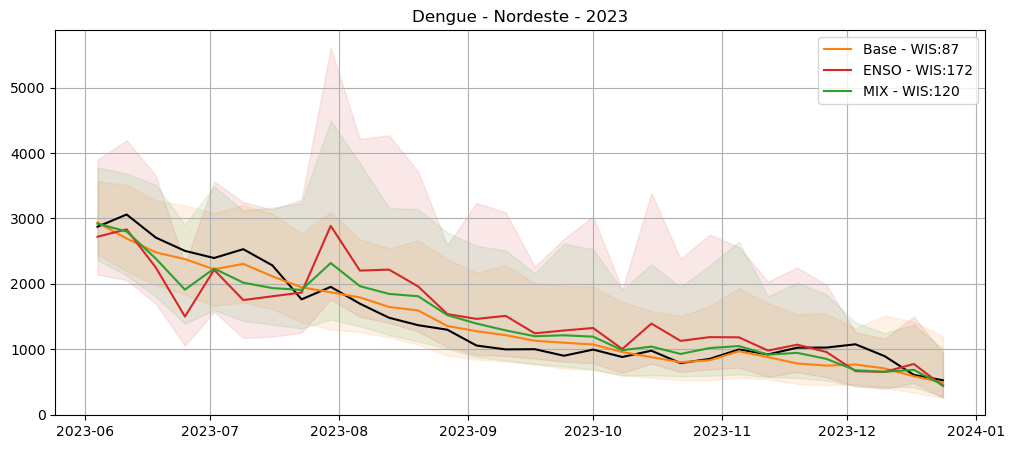

Centro-Oeste
Loading predictions/preds_dengue_Centro-Oeste_2023_base_22.csv
Loading predictions/preds_dengue_Centro-Oeste_2023_enso_22.csv
Loading predictions/preds_dengue_Centro-Oeste_2023_mix_22.csv


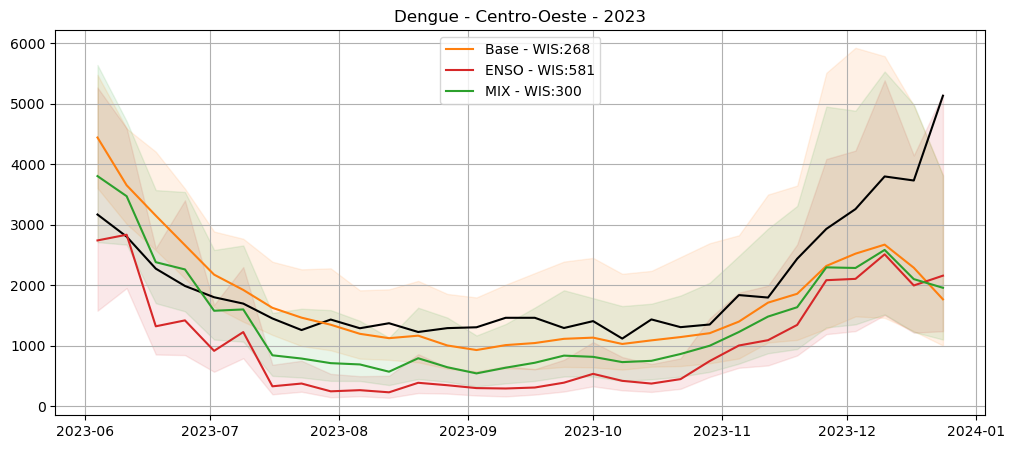

Norte
Loading predictions/preds_dengue_Norte_2023_base_22.csv
Loading predictions/preds_dengue_Norte_2023_enso_22.csv
Loading predictions/preds_dengue_Norte_2023_mix_22.csv


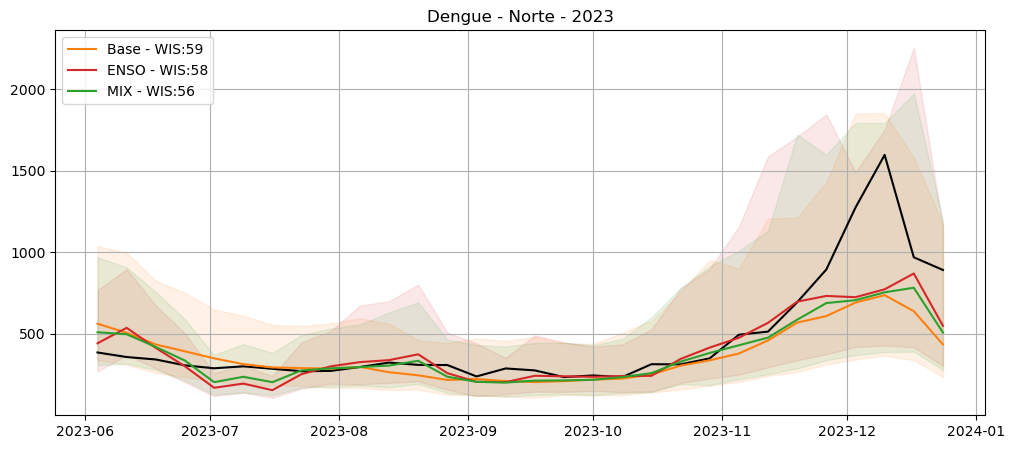

In [5]:
for region in regioes_estados.keys(): 

    print(region)

    df_reg = df.loc[df.uf.isin(regioes_estados[region])]
    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]

    df_reg_agg = df_reg.groupby(['date', 'epiweek'])[['casos']].sum().reset_index()
    df_reg_agg = df_reg_agg.loc[(df_reg_agg.epiweek >= int(f'{TEST_YEAR}23')) & (df_reg_agg.epiweek <= int(f'{TEST_YEAR}52'))]

    df_preds1, mean_sc1 = make_pred(df_reg_agg, df_reg, None, doenca, region, TEST_YEAR, columns_to_normalize, model_name = model_base, media = True )

    df_preds2, mean_sc2 = make_pred(df_reg_agg, df_reg, enso, doenca, region, TEST_YEAR, columns_to_normalize_enso, model_name = model_enso, media = True )

    df_preds3, mean_sc3 = make_pred(df_reg_agg, df_reg, enso, doenca, region, TEST_YEAR, columns_to_normalize_enso, model_name = model_mix, media = True )


    _,ax=plt.subplots(figsize = (12,5))

    ax.plot(df_reg_agg.date, df_reg_agg.casos, color = 'black')

    ax.plot(df_preds1.date, df_preds1.pred, color = 'tab:orange', label = f'Base - WIS:{int(mean_sc1)}')
    ax.fill_between(df_preds1.date, df_preds1.lower_90, df_preds1.upper_90, color = 'tab:orange', alpha = 0.1)


    ax.plot(df_preds2.date, df_preds2.pred, color = 'tab:red', label = f'ENSO - WIS:{int(mean_sc2)}')
    ax.fill_between(df_preds2.date, df_preds2.lower_90, df_preds2.upper_90, color = 'tab:red', alpha = 0.1)

    ax.plot(df_preds3.date, df_preds3.pred, color = 'tab:green', label = f'MIX - WIS:{int(mean_sc3)}')
    ax.fill_between(df_preds3.date, df_preds3.lower_90, df_preds3.upper_90, color = 'tab:green', alpha = 0.1)

    ax.legend()
    ax.grid()
    ax.set_title(f'{doenca.capitalize()} - {region} - {TEST_YEAR}' )

    plt.savefig(f'figures/comp_models_{doenca}_{region}_{TEST_YEAR}', dpi =300, bbox_inches = 'tight')

    plt.show()


Comp model  by state: 

In [6]:
def plot_state(ax_, df, state): 
    df_reg = df.loc[df.uf.isin([state])]
    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]

    df_reg_agg = df_reg.groupby(['date', 'epiweek'])[['casos']].sum().reset_index()
    df_reg_agg = df_reg_agg.loc[(df_reg_agg.epiweek >= int(f'{TEST_YEAR}23')) & (df_reg_agg.epiweek <= int(f'{TEST_YEAR}52'))]

    df_preds1, mean_sc1 = make_pred(df_reg_agg, df_reg, None, doenca, state, TEST_YEAR, columns_to_normalize, model_name = model_base, media = True )

    df_preds2, mean_sc2 = make_pred(df_reg_agg, df_reg, enso, doenca, state, TEST_YEAR, columns_to_normalize_enso, model_name = model_enso, media = True )

    df_preds3, mean_sc3 = make_pred(df_reg_agg, df_reg, enso, doenca, state, TEST_YEAR, columns_to_normalize_enso, model_name = model_mix, media = True )

    ax_.plot(df_reg_agg.date, df_reg_agg.casos, color = 'black')

    ax_.plot(df_preds1.date, df_preds1.pred, color = 'tab:orange', label = f'Base - WIS:{int(mean_sc1)}')
    ax_.fill_between(df_preds1.date, df_preds1.lower_90, df_preds1.upper_90, color = 'tab:orange', alpha = 0.1)

    ax_.plot(df_preds2.date, df_preds2.pred, color = 'tab:red', label = f'ENSO - WIS:{int(mean_sc2)}')
    ax_.fill_between(df_preds2.date, df_preds2.lower_90, df_preds2.upper_90, color = 'tab:red', alpha = 0.1)

    ax_.plot(df_preds3.date, df_preds3.pred, color = 'tab:green', label = f'MIX - WIS:{int(mean_sc3)}')
    ax_.fill_between(df_preds3.date, df_preds3.lower_90, df_preds3.upper_90, color = 'tab:green', alpha = 0.1)

    ax_.legend()
    ax_.grid()
    ax_.set_title(f'{state} - {TEST_YEAR}' )
    ax_.tick_params(rotation = 30)


In [7]:
regioes_estados[region]

['RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO']

Loading predictions/preds_dengue_SC_2023_base_22.csv
Loading predictions/preds_dengue_SC_2023_enso_22.csv
Loading predictions/preds_dengue_SC_2023_mix_22.csv
Loading predictions/preds_dengue_PR_2023_base_22.csv
Loading predictions/preds_dengue_PR_2023_enso_22.csv
Loading predictions/preds_dengue_PR_2023_mix_22.csv
Loading predictions/preds_dengue_RS_2023_base_22.csv
Loading predictions/preds_dengue_RS_2023_enso_22.csv
Loading predictions/preds_dengue_RS_2023_mix_22.csv


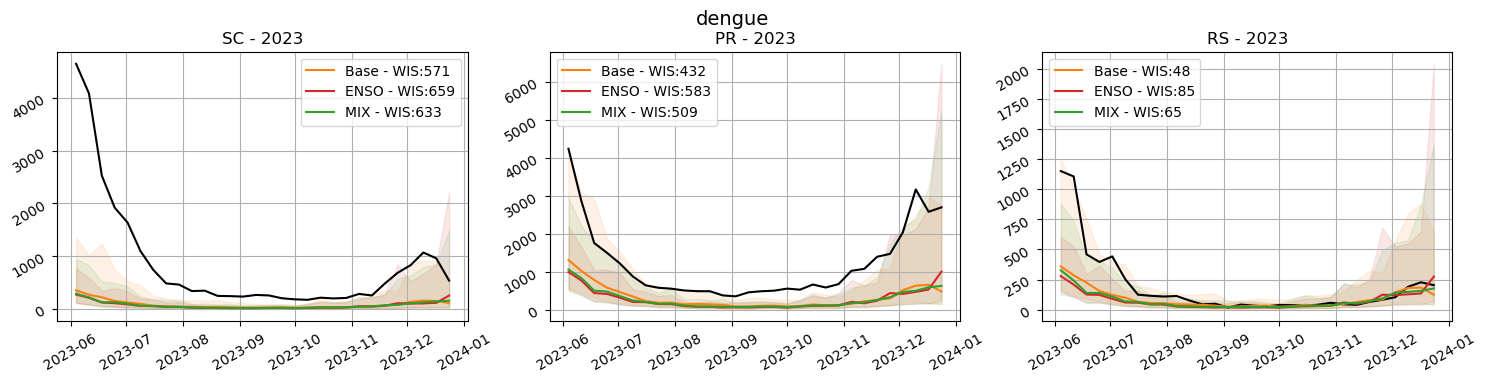

In [8]:
region = 'Sul'

_, ax = plt.subplots(1,3, figsize = (18, 3.5))

axs = ax.ravel()

for state,ax_ in zip(regioes_estados[region], axs): 

    plot_state(ax_, df, state)

    ax_.tick_params(rotation = 30)
plt.suptitle(doenca, fontsize = 14, y = 1)
    
plt.savefig(f'figures/comp_models_state_{doenca}_{region}_{TEST_YEAR}', dpi =300, bbox_inches = 'tight')


Loading predictions/preds_dengue_SP_2023_base_22.csv
Loading predictions/preds_dengue_SP_2023_enso_22.csv
Loading predictions/preds_dengue_SP_2023_mix_22.csv
Loading predictions/preds_dengue_MG_2023_base_22.csv
Loading predictions/preds_dengue_MG_2023_enso_22.csv
Loading predictions/preds_dengue_MG_2023_mix_22.csv
Loading predictions/preds_dengue_RJ_2023_base_22.csv
Loading predictions/preds_dengue_RJ_2023_enso_22.csv
Loading predictions/preds_dengue_RJ_2023_mix_22.csv
Loading predictions/preds_dengue_ES_2023_base_22.csv
Loading predictions/preds_dengue_ES_2023_enso_22.csv
Loading predictions/preds_dengue_ES_2023_mix_22.csv


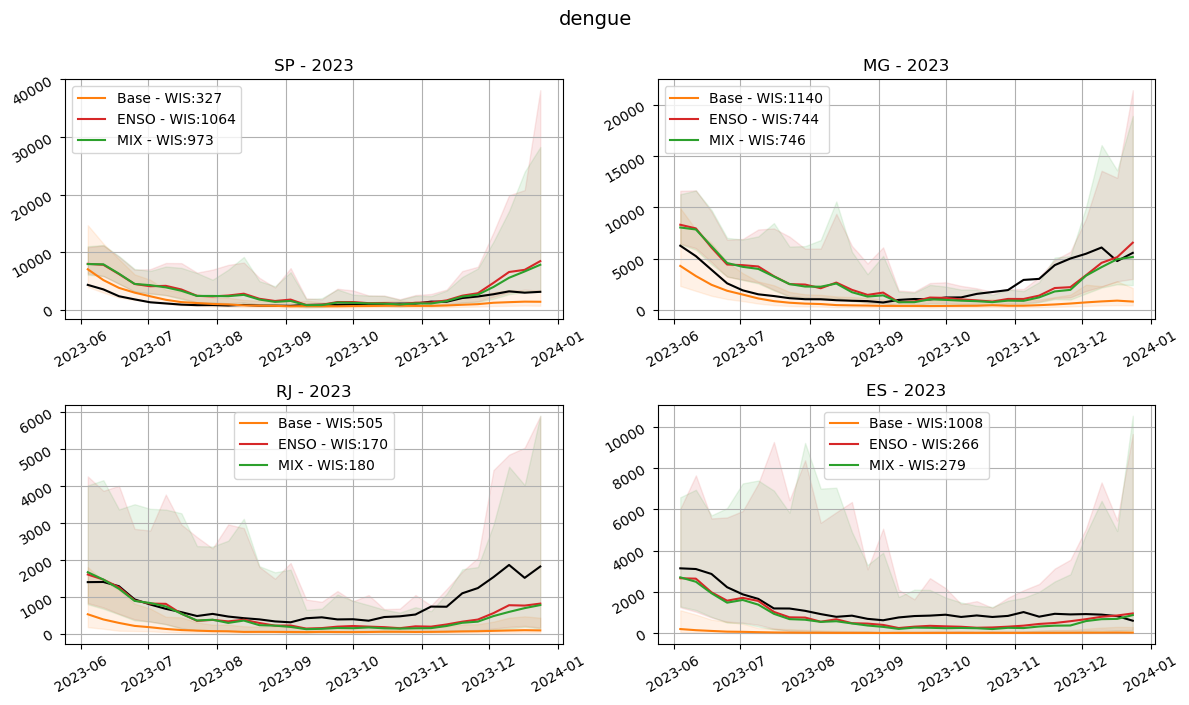

In [9]:
region = 'Sudeste'

_, ax = plt.subplots(2,2, figsize = (12, 7))

axs = ax.ravel()

for state,ax_ in zip(regioes_estados[region], axs): 

    plot_state(ax_, df, state)

plt.suptitle(doenca, fontsize = 14, y = 1)
plt.tight_layout()
plt.savefig(f'figures/comp_models_state_{doenca}_{region}_{TEST_YEAR}', dpi =300, bbox_inches = 'tight')

Loading predictions/preds_dengue_DF_2023_base_22.csv
Loading predictions/preds_dengue_DF_2023_enso_22.csv
Loading predictions/preds_dengue_DF_2023_mix_22.csv
Loading predictions/preds_dengue_MT_2023_base_22.csv
Loading predictions/preds_dengue_MT_2023_enso_22.csv
Loading predictions/preds_dengue_MT_2023_mix_22.csv
Loading predictions/preds_dengue_MS_2023_base_22.csv
Loading predictions/preds_dengue_MS_2023_enso_22.csv
Loading predictions/preds_dengue_MS_2023_mix_22.csv
Loading predictions/preds_dengue_GO_2023_base_22.csv
Loading predictions/preds_dengue_GO_2023_enso_22.csv
Loading predictions/preds_dengue_GO_2023_mix_22.csv


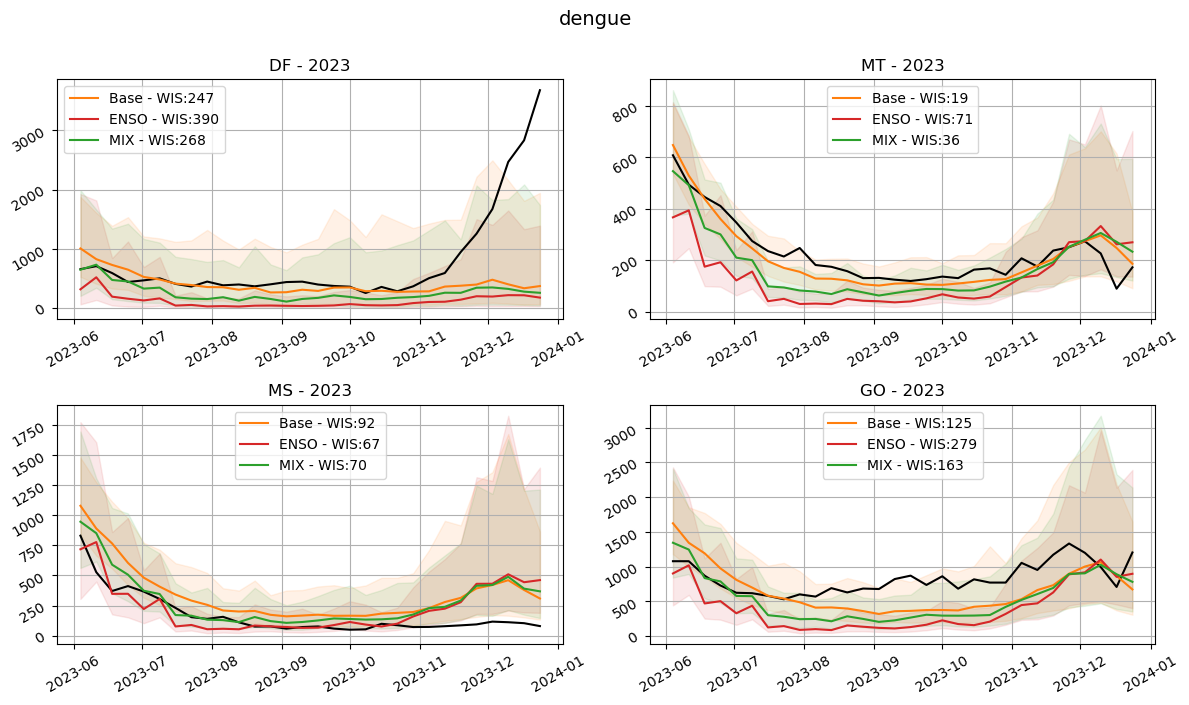

In [10]:
region = 'Centro-Oeste'

_, ax = plt.subplots(2,2, figsize = (12, 7))

axs = ax.ravel()

for state,ax_ in zip(regioes_estados[region], axs): 

    plot_state(ax_, df, state)

plt.suptitle(doenca, fontsize = 14, y = 1)
plt.tight_layout()
plt.savefig(f'figures/comp_models_state_{doenca}_{region}_{TEST_YEAR}', dpi =300, bbox_inches = 'tight')

Loading predictions/preds_dengue_BA_2023_base_22.csv
Loading predictions/preds_dengue_BA_2023_enso_22.csv
Loading predictions/preds_dengue_BA_2023_mix_22.csv
Loading predictions/preds_dengue_CE_2023_base_22.csv
Loading predictions/preds_dengue_CE_2023_enso_22.csv
Loading predictions/preds_dengue_CE_2023_mix_22.csv
Loading predictions/preds_dengue_PE_2023_base_22.csv
Loading predictions/preds_dengue_PE_2023_enso_22.csv
Loading predictions/preds_dengue_PE_2023_mix_22.csv
Loading predictions/preds_dengue_PB_2023_base_22.csv
Loading predictions/preds_dengue_PB_2023_enso_22.csv
Loading predictions/preds_dengue_PB_2023_mix_22.csv
Loading predictions/preds_dengue_PI_2023_base_22.csv
Loading predictions/preds_dengue_PI_2023_enso_22.csv
Loading predictions/preds_dengue_PI_2023_mix_22.csv
Loading predictions/preds_dengue_RN_2023_base_22.csv
Loading predictions/preds_dengue_RN_2023_enso_22.csv
Loading predictions/preds_dengue_RN_2023_mix_22.csv
Loading predictions/preds_dengue_MA_2023_base_22.csv

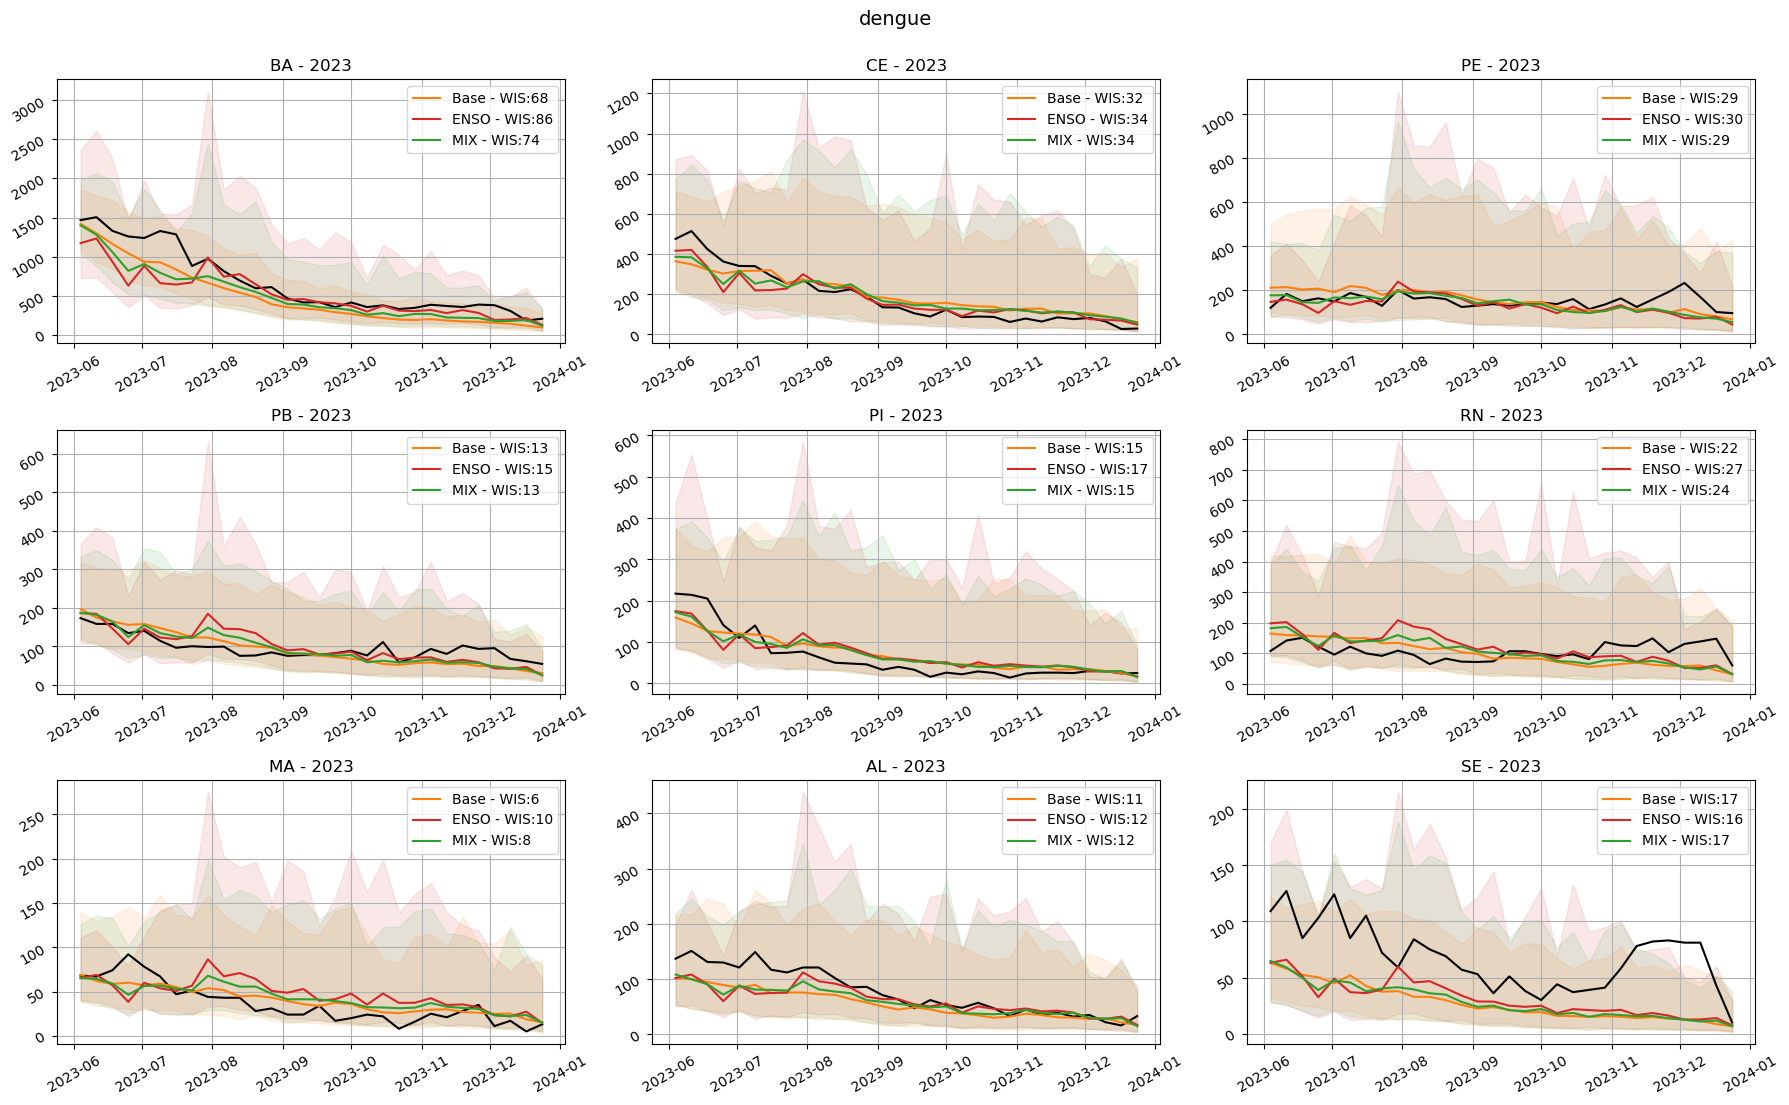

In [11]:
region = 'Nordeste'

_, ax = plt.subplots(3,3, figsize = (18, 11))

axs = ax.ravel()

for state,ax_ in zip(regioes_estados[region], axs): 

    plot_state(ax_, df, state)

plt.suptitle(doenca, fontsize = 14, y = 1)
plt.tight_layout()
plt.savefig(f'figures/comp_models_state_{doenca}_{region}_{TEST_YEAR}', dpi =300, bbox_inches = 'tight')

Loading predictions/preds_dengue_RO_2023_base_22.csv
Loading predictions/preds_dengue_RO_2023_enso_22.csv
Loading predictions/preds_dengue_RO_2023_mix_22.csv
Loading predictions/preds_dengue_AC_2023_base_22.csv
Loading predictions/preds_dengue_AC_2023_enso_22.csv
Loading predictions/preds_dengue_AC_2023_mix_22.csv
Loading predictions/preds_dengue_AM_2023_base_22.csv
Loading predictions/preds_dengue_AM_2023_enso_22.csv
Loading predictions/preds_dengue_AM_2023_mix_22.csv
Loading predictions/preds_dengue_RR_2023_base_22.csv
Loading predictions/preds_dengue_RR_2023_enso_22.csv
Loading predictions/preds_dengue_RR_2023_mix_22.csv
Loading predictions/preds_dengue_PA_2023_base_22.csv
Loading predictions/preds_dengue_PA_2023_enso_22.csv
Loading predictions/preds_dengue_PA_2023_mix_22.csv
Loading predictions/preds_dengue_AP_2023_base_22.csv
Loading predictions/preds_dengue_AP_2023_enso_22.csv
Loading predictions/preds_dengue_AP_2023_mix_22.csv
Loading predictions/preds_dengue_TO_2023_base_22.csv

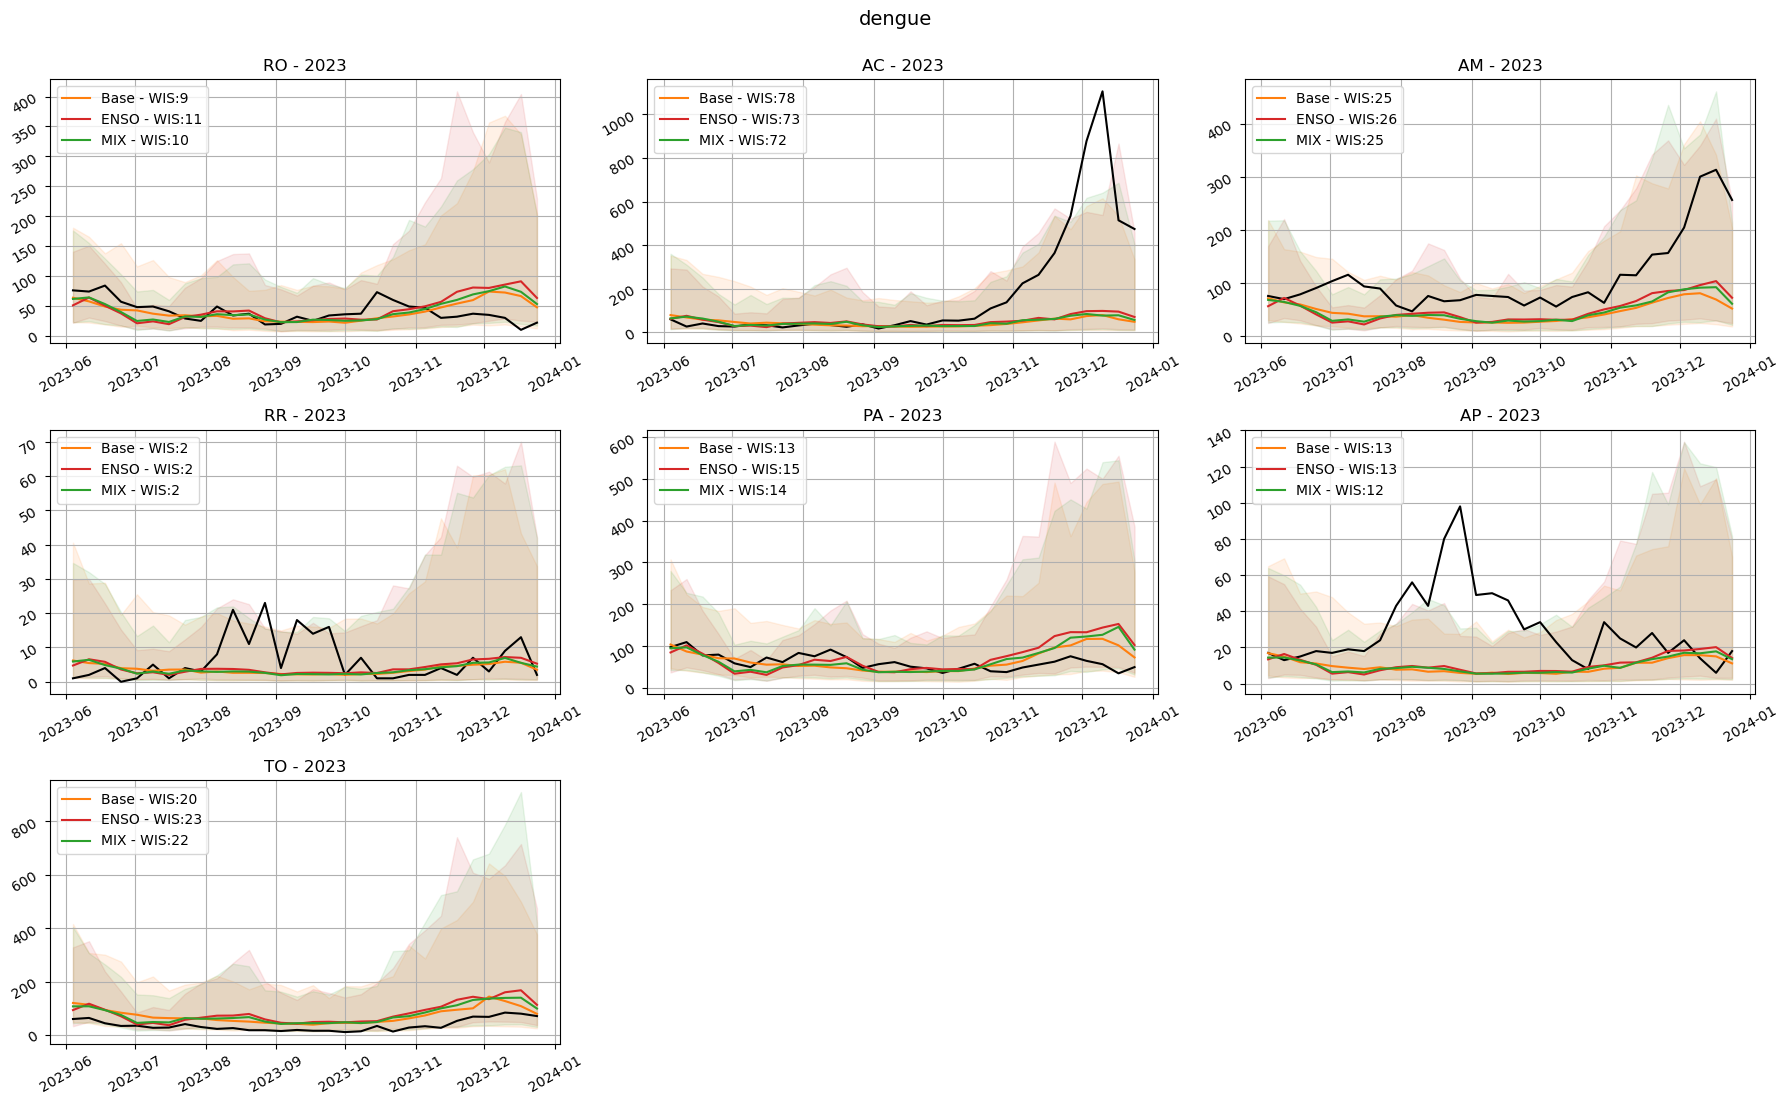

In [12]:
region = 'Norte'

_, ax = plt.subplots(3,3, figsize = (18, 11))

axs = ax.ravel()

for state,ax_ in zip(regioes_estados[region], axs): 

    plot_state(ax_, df, state)

axs[-2].axis('off')
axs[-1].axis('off')

plt.suptitle(doenca, fontsize = 14, y = 1)
plt.tight_layout()
plt.savefig(f'figures/comp_models_state_{doenca}_{region}_{TEST_YEAR}', dpi =300, bbox_inches = 'tight')